In [21]:
import pandas as pd

df = pd.read_csv("power.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

energy = df[["date", "Appliances"]]

In [37]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 1.7 MB/s eta 0:01:00
   ---------------------------------------- 1.0/101.7 MB 1.7 MB/s eta 0:00:59
    --------------------------------------- 1.3/101.7 MB 1.5 MB/s eta 0:01:06
    --------------------------------------- 1.6/101.7 MB 1.4 MB/s eta 0:01:10
    --------------------------------------- 1.8/101.7 MB 1.4 MB/s eta 0:01:12
    --------------------------------------- 2.1/101.7 MB 1.4 MB/s eta 0:01:10
    --------------------------------------- 2.4/101.7 MB 1.5 MB/s eta 0:01:06
   - -------------------------------------- 2.6/101.7 MB 1.5 MB/s eta 0:01:08
   - -------------------------------------- 2.9/101.7 MB 1.4 MB/s eta 0:01:10
   - ---------

In [38]:
df

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,...,17.033333,45.5300,6.600000,733.5,92.000000,7.000000,63.000000,5.300000,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,...,17.066667,45.5600,6.483333,733.6,92.000000,6.666667,59.166667,5.200000,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,...,17.000000,45.5000,6.366667,733.7,92.000000,6.333333,55.333333,5.100000,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.250000,733.8,92.000000,6.000000,51.500000,5.000000,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.133333,733.9,92.000000,5.666667,47.666667,4.900000,10.084097,10.084097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,2016-05-27 17:20:00,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,...,23.200000,46.7900,22.733333,755.2,55.666667,3.333333,23.666667,13.333333,43.096812,43.096812
19731,2016-05-27 17:30:00,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,...,23.200000,46.7900,22.600000,755.2,56.000000,3.500000,24.500000,13.300000,49.282940,49.282940
19732,2016-05-27 17:40:00,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,...,23.200000,46.7900,22.466667,755.2,56.333333,3.666667,25.333333,13.266667,29.199117,29.199117
19733,2016-05-27 17:50:00,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,...,23.200000,46.8175,22.333333,755.2,56.666667,3.833333,26.166667,13.233333,6.322784,6.322784


## EDA Enhancement

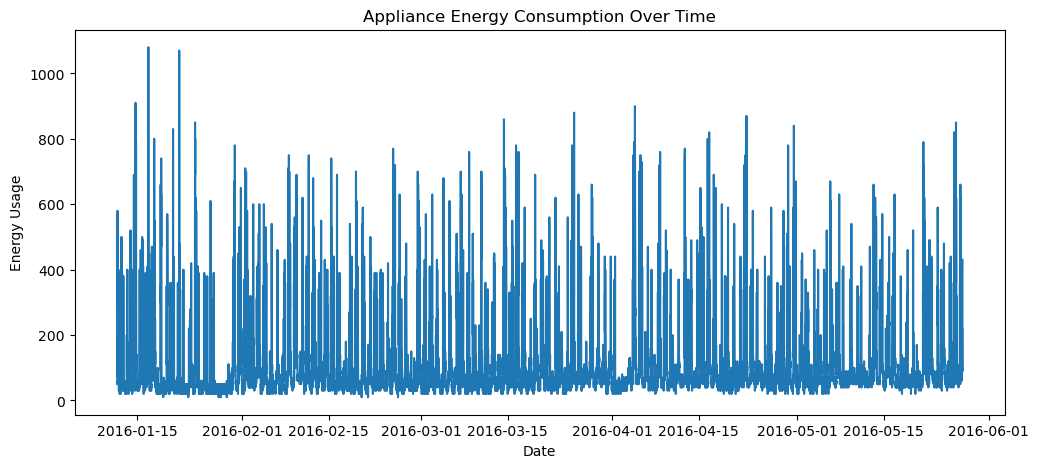

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(energy["date"], energy["Appliances"])

plt.title("Appliance Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Usage")

plt.show()

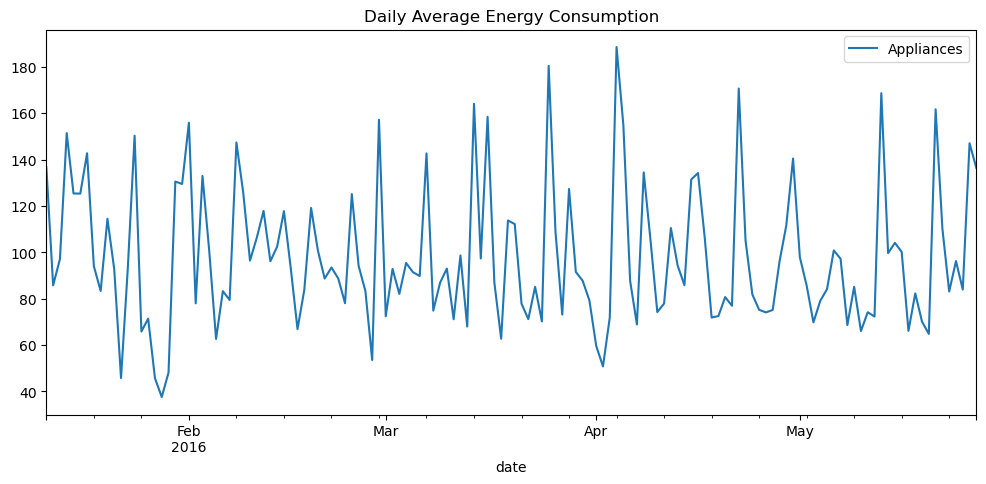

In [40]:
daily = energy.set_index("date").resample("D").mean()

daily.plot(figsize=(12,5))
plt.title("Daily Average Energy Consumption")
plt.show()

## Arima

In [41]:
from statsmodels.tsa.arima.model import ARIMA

daily = energy.set_index("date").resample("D").mean()

train = daily[:-30]
test = daily[-30:]

arima_model = ARIMA(
    train["Appliances"],
    order=(5,1,0)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(
    steps=len(test)
)

#### evaluation

In [42]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae_arima = mean_absolute_error(
    test["Appliances"],
    arima_pred
)

rmse_arima = np.sqrt(
    ((test["Appliances"] - arima_pred)**2).mean()
)

print(mae_arima)
print(rmse_arima)

21.02863473682935
30.235890250587122


## XGBoost

In [43]:
daily = daily.reset_index()

daily["day"] = daily["date"].dt.day
daily["month"] = daily["date"].dt.month
daily["weekday"] = daily["date"].dt.weekday

In [44]:
X = daily[["day", "month", "weekday"]]

y = daily["Appliances"]

split = len(daily) - 30

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [45]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)

## evaluation

In [46]:
mae_xgb = mean_absolute_error(
    y_test,
    xgb_pred
)

rmse_xgb = np.sqrt(
    ((y_test - xgb_pred)**2).mean()
)

print(mae_xgb)
print(rmse_xgb)

28.64147899807856
35.928874428978666


## Models comparision

In [47]:
comparison = pd.DataFrame({
    "Model":[
        "ARIMA",
        "XGBoost"
    ],
    "MAE":[
        mae_arima,
        mae_xgb
    ]
})

print(comparison)

     Model        MAE
0    ARIMA  21.028635
1  XGBoost  28.641479


## Actual vs Forecast